In [ ]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
%%bash
# Endpoint TAP de VizieR
ENDPOINT="https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync?request=doQuery&lang=ADQL&format=csv&query="

# Consulta ADQL con indexación espacial dual (Súper rápida)
QUERY_RAW="SELECT g.Source, g.PM, g.Plx, g.RA_ICRS, g.DE_ICRS, g.Gmag, a.W1mag, a.RAJ2000, a.DEJ2000 FROM \"I/355/gaiadr3\" AS g LEFT JOIN \"II/328/allwise\" AS a ON 1 = CONTAINS(POINT('ICRS', a.RAJ2000, a.DEJ2000), CIRCLE('ICRS', 135.5, 0.5, 0.501)) AND DISTANCE(POINT('ICRS', g.RA_ICRS, g.DE_ICRS), POINT('ICRS', a.RAJ2000, a.DEJ2000)) < 0.0005555555555555556 WHERE 1 = CONTAINS(POINT('ICRS', g.RA_ICRS, g.DE_ICRS), CIRCLE('ICRS', 135.5, 0.5, 0.5))"

# Formatear espacios (+), comillas (%22) y el signo menor que (%3C)
QUERY_URL=$(echo "$QUERY_RAW" | sed 's/ /+/g' | sed 's/"/%22/g' | sed 's/</%3C/g')

# Descargar el CSV
wget -q -O campo_profundo.csv "${ENDPOINT}${QUERY_URL}"

# Confirmar filas obtenidas
echo "Descarga completada. Filas obtenidas (incluyendo encabezado):"
wc -l campo_profundo.csv

Descarga completada. Filas obtenidas (incluyendo encabezado):
5059 campo_profundo.csv


In [ ]:
# Cargar los datos del archivo CSV descargado
df = pd.read_csv('campo_profundo.csv')

# Eliminar registros con valores faltantes en magnitudes (Gmag, W1mag) y paralaje (Plx)
df_limpio = df.dropna(subset=['Gmag', 'W1mag', 'Plx'])

# Aislar la población galáctica aplicando el umbral de paralaje (> 0.05 mas)
df_galactico = df_limpio[df_limpio['Plx'] > 0.05]

# Visualizar las primeras filas del conjunto de datos filtrado
df_galactico.head()

,Source,PM,Plx,RA_ICRS,DE_ICRS,Gmag,W1mag,RAJ2000,DEJ2000
0,576463677177727104,6.790,5.6234,135.171177,0.148619,20.026037,15.817,135.171397,0.148673
2,576463707240934400,80.084,6.3935,135.140584,0.153238,15.976371,12.282,135.140548,0.153348
3,576463745896390400,2.756,0.7983,135.155927,0.156563,16.363176,14.528,135.156006,0.156564
4,576463745896389888,6.347,0.4631,135.158047,0.156470,16.236700,14.872,135.158074,0.156475
6,576463913399365248,4.460,0.3126,135.138806,0.159551,18.048435,16.118,135.138735,0.159538


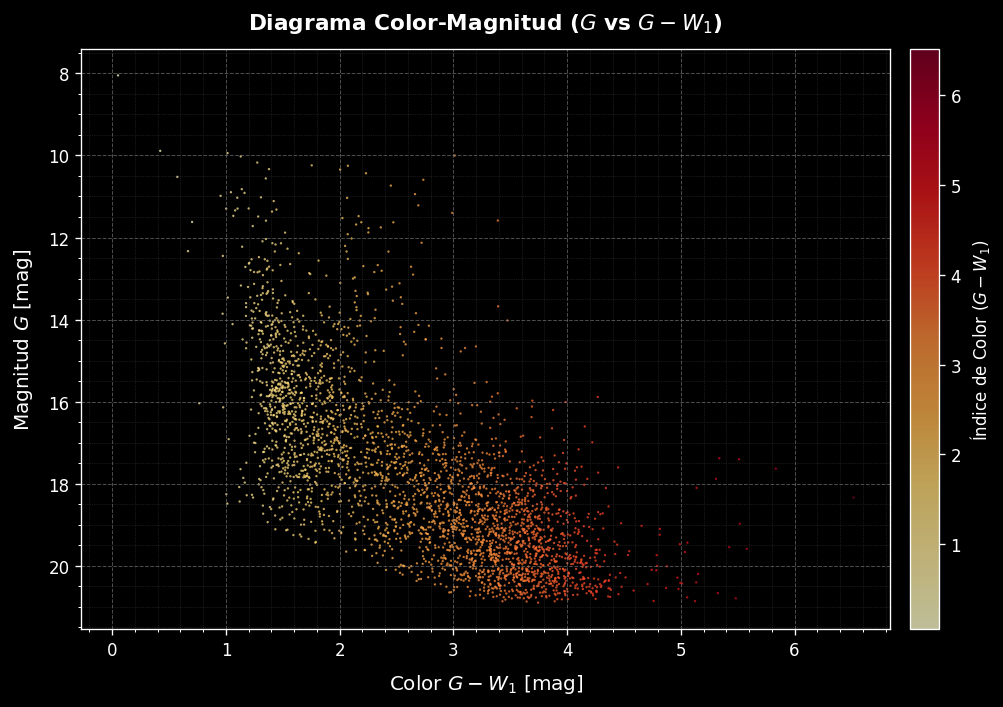

In [ ]:
# Extraer las magnitudes ópticas (G) e infrarrojas (W1) a arreglos de NumPy
G = df_galactico['Gmag'].to_numpy()
W1 = df_galactico['W1mag'].to_numpy()

# Calcular vectorialmente el índice de color óptico-infrarrojo
X = G - W1

# Aplicar estilo visual de fondo oscuro
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9, 6), dpi=120)

# Activar marcas secundarias necesarias para la cuadrícula fina
ax.minorticks_on()

# Crear el gráfico de dispersión (Color X en horizontal, Magnitud G en vertical)
sc = ax.scatter(X, G, s=2, c=X, cmap='YlOrRd', alpha=0.75, edgecolors='none')

# Invertir el eje Y siguiendo la convención astronómica de magnitudes
ax.invert_yaxis()

# Configurar la cuadrícula gris para divisiones principales y secundarias
ax.grid(True, which='major', color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
ax.grid(True, which='minor', color='gray', linestyle=':', linewidth=0.4, alpha=0.4)

# Agregar la barra de color con su respectiva etiqueta
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Índice de Color ($G - W_1$)', fontsize=10)

# Asignar etiquetas de ejes y título con tipografía LaTeX
ax.set_xlabel('Color $G - W_1$ [mag]', fontsize=12, labelpad=8)
ax.set_ylabel('Magnitud $G$ [mag]', fontsize=12, labelpad=8)
ax.set_title('Diagrama Color-Magnitud ($G$ vs $G - W_1$)', fontsize=13, fontweight='bold', pad=12)

# Ajustar márgenes y renderizar la figura
plt.tight_layout()
plt.show()